In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
file_path = (r"C:\Users\Nate\Desktop\descriptors.csv")
df = pd.read_csv(file_path)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77901 entries, 0 to 77900
Columns: 124 entries, MaxEStateIndex to rt
dtypes: float64(105), int64(19)
memory usage: 73.7 MB


,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
count,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.00000,77901.0,...,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000
mean,12.398119,-1.074155,12.398119,0.123069,0.684043,384.342535,362.490113,383.934342,141.91330,0.0,...,0.936689,7.341241,4.739734,0.126276,0.612932,0.739207,3.670338,3.129502,103.663140,808.600919
std,1.768844,1.532360,1.768844,0.135011,0.142415,59.875586,56.973794,59.787840,22.28797,0.0,...,0.751684,1.729306,1.708636,0.361973,0.666931,0.764066,0.854941,1.106216,16.542201,174.701901
min,2.237870,-6.515426,2.237870,0.000001,0.062954,113.160000,102.072000,113.084064,46.00000,0.0,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.204800,26.091900,175.900000
25%,12.352796,-1.086454,12.352796,0.036977,0.579100,347.415000,327.275000,347.110376,128.00000,0.0,...,0.000000,6.000000,4.000000,0.000000,0.000000,0.000000,3.000000,2.428100,93.357500,668.900000
50%,12.779807,-0.354252,12.779807,0.083793,0.698606,388.516000,366.301000,388.174670,144.00000,0.0,...,1.000000,7.000000,5.000000,0.000000,1.000000,1.000000,4.000000,3.171300,104.659200,779.800000
75%,13.148829,-0.110752,13.148829,0.159867,0.791431,426.498000,402.326000,426.109483,158.00000,0.0,...,1.000000,8.000000,6.000000,0.000000,1.000000,1.000000,4.000000,3.869600,115.134700,917.000000
max,17.398044,1.274123,17.398044,1.274123,0.948272,741.461000,722.309000,738.875187,268.00000,0.0,...,11.000000,17.000000,15.000000,5.000000,7.000000,7.000000,11.000000,8.954000,191.202500,1471.700000


In [4]:
df.head(10)

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
0,12.990628,-0.335181,12.990628,0.035905,0.760602,414.333,389.133,413.127297,148,0,...,0,8,4,0,2,2,3,2.9109,105.3190,687.8
1,12.609649,-3.521975,12.609649,0.030555,0.702317,369.487,342.271,369.172227,140,0,...,2,8,7,0,1,1,2,1.2851,97.7354,590.7
2,11.164259,-0.177407,11.164259,0.137593,0.610213,161.160,154.104,161.047678,60,0,...,2,3,0,0,0,0,2,1.2337,46.2335,583.6
3,11.161791,-0.252097,11.161791,0.221895,0.900805,260.337,240.177,260.152478,102,0,...,1,4,3,0,2,2,3,1.8035,73.0347,579.0
4,11.266054,-0.615607,11.266054,0.048741,0.656633,279.340,258.172,279.158292,110,0,...,4,6,5,0,0,0,2,0.9840,78.1769,603.1
5,12.386283,-4.565776,12.386283,0.311786,0.740582,203.238,193.158,203.041628,72,0,...,1,5,3,0,0,0,1,0.8460,47.4942,653.1
6,11.531255,-0.169277,11.531255,0.169277,0.665746,225.251,214.163,225.090212,84,0,...,2,4,1,0,0,0,3,2.0757,66.9899,705.6
7,5.698502,0.432778,5.698502,0.432778,0.616936,133.194,122.106,133.089149,52,0,...,1,1,1,1,0,1,2,1.5012,41.7754,621.0
8,3.503917,0.550983,3.503917,0.550983,0.842257,303.187,285.043,303.048398,78,0,...,1,2,4,0,0,0,1,3.2202,70.5967,745.6
9,10.456019,-0.472222,10.456019,0.370370,0.396109,116.120,108.056,116.058577,46,0,...,2,4,0,0,1,1,1,-1.0648,26.0919,620.6


In [5]:
df.isna().sum()

MaxEStateIndex       0
MinEStateIndex       0
MaxAbsEStateIndex    0
MinAbsEStateIndex    0
qed                  0
                    ..
NumSaturatedRings    0
RingCount            0
MolLogP              0
MolMR                0
rt                   0
Length: 124, dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

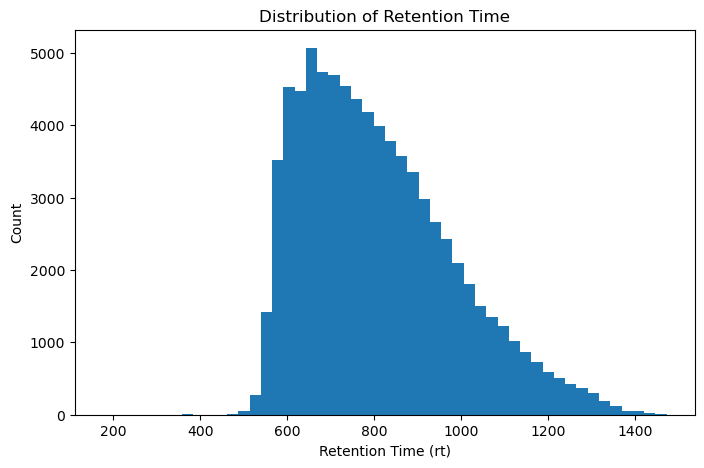

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["rt"], bins=50)
plt.xlabel("Retention Time (rt)")
plt.ylabel("Count")
plt.title("Distribution of Retention Time")
plt.show()

In [8]:
X = df.drop(columns=["rt"])
y = df["rt"]

print(X.shape, y.shape)

(77901, 123) (77901,)


In [9]:
nunique = X.nunique()
zero_var_cols = nunique[nunique <= 1].index.tolist()

print("Zero-variance columns:", len(zero_var_cols))

X = X.drop(columns=zero_var_cols)
print(X.shape)

Zero-variance columns: 3
(77901, 120)


In [10]:
corr_with_rt = X.copy()
corr_with_rt["rt"] = y
corr_series = corr_with_rt.corr(numeric_only=True)["rt"].drop("rt").sort_values()

top_negative = corr_series.head(10)
top_positive = corr_series.tail(10)

print("Top negative correlations:")
print(top_negative)

print("\nTop positive correlations:")
print(top_positive)

Top negative correlations:
SlogP_VSA2                 -0.340061
qed                        -0.315568
FractionCSP3               -0.309459
SMR_VSA6                   -0.295496
PEOE_VSA8                  -0.273705
NumSaturatedHeterocycles   -0.246775
NumAliphaticHeterocycles   -0.233101
NumSaturatedRings          -0.227395
NumAliphaticRings          -0.214850
NHOHCount                  -0.207377
Name: rt, dtype: float64

Top positive correlations:
SlogP_VSA8                0.298231
VSA_EState6               0.298343
SMR_VSA7                  0.318440
PEOE_VSA6                 0.320308
SMR_VSA9                  0.325657
SlogP_VSA6                0.329346
NumAromaticRings          0.338223
BertzCT                   0.341972
NumAromaticCarbocycles    0.380441
MolLogP                   0.512212
Name: rt, dtype: float64


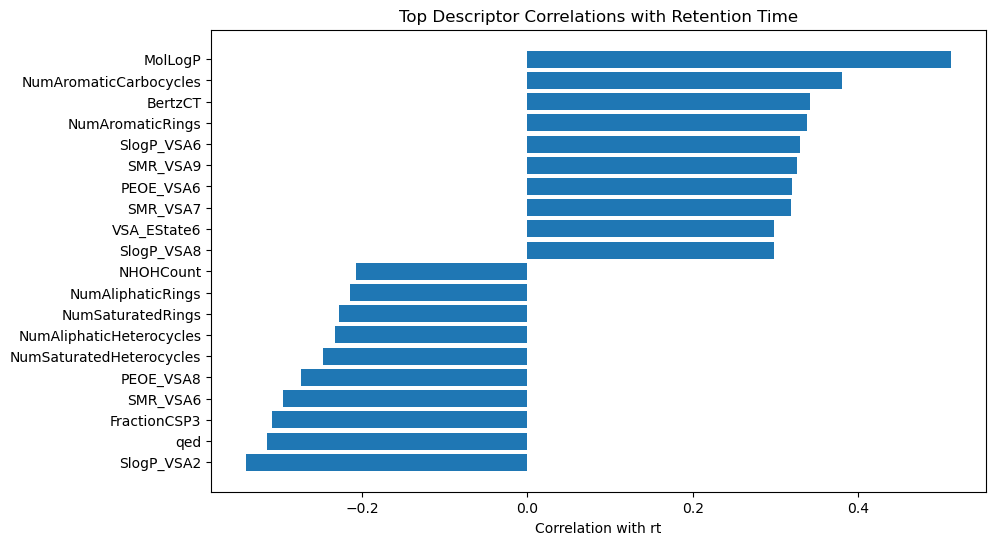

In [11]:
top_corr = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 6))
plt.barh(top_corr.index, top_corr.values)
plt.xlabel("Correlation with rt")
plt.title("Top Descriptor Correlations with Retention Time")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(62320, 120) (15581, 120)


In [13]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)

In [14]:
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = mean_squared_error(y_test, linear_preds) ** 0.5
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression")
print("MAE:", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²:", round(linear_r2, 4))

Linear Regression
MAE: 84.2606
RMSE: 111.8998
R²: 0.5923


In [15]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

In [16]:
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = mean_squared_error(y_test, ridge_preds) ** 0.5
ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge Regression")
print("MAE:", round(ridge_mae, 4))
print("RMSE:", round(ridge_rmse, 4))
print("R²:", round(ridge_r2, 4))

Ridge Regression
MAE: 85.3065
RMSE: 112.9261
R²: 0.5848


In [18]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [linear_mae, ridge_mae],
    "RMSE": [linear_rmse, ridge_rmse],
    "R2": [linear_r2, ridge_r2]
})

results.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,84.2606,111.8998,0.5923
1,Ridge Regression,85.3065,112.9261,0.5848


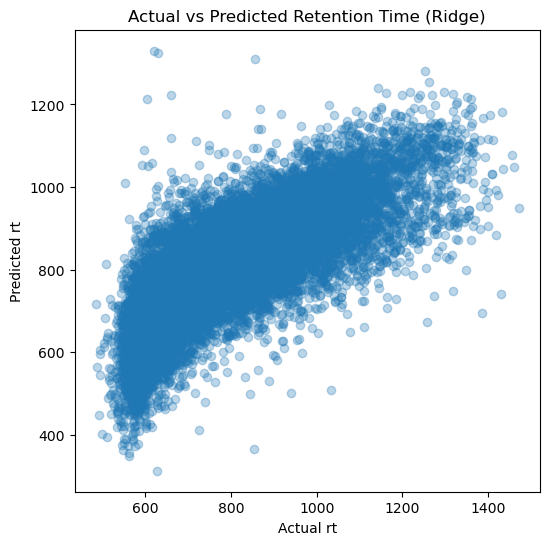

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, ridge_preds, alpha=0.3)
plt.xlabel("Actual rt")
plt.ylabel("Predicted rt")
plt.title("Actual vs Predicted Retention Time (Ridge)")
plt.show()

In [20]:
ridge_coeffs = pd.Series(
    ridge_model.named_steps["model"].coef_,
    index=X.columns
).sort_values()

top_negative_coef = ridge_coeffs.head(10)
top_positive_coef = ridge_coeffs.tail(10)

print("Top negative Ridge coefficients:")
print(top_negative_coef)

print("\nTop positive Ridge coefficients:")
print(top_positive_coef)

Top negative Ridge coefficients:
HeavyAtomCount   -515.345017
VSA_EState1      -406.740357
VSA_EState2      -245.539434
SlogP_VSA2       -211.798394
Chi1v            -184.768340
VSA_EState6      -156.471196
SMR_VSA10        -154.130598
LabuteASA        -153.984347
HallKierAlpha    -128.123082
VSA_EState3      -116.146565
dtype: float64

Top positive Ridge coefficients:
TPSA                    37.047915
NumHeteroatoms          75.007911
SlogP_VSA12             89.722219
Chi2v                   97.728327
SMR_VSA1                99.293921
HeavyAtomMolWt         128.716709
Chi1n                  173.992504
Chi0                   423.499489
MolMR                  474.513869
NumValenceElectrons    548.011694
dtype: float64


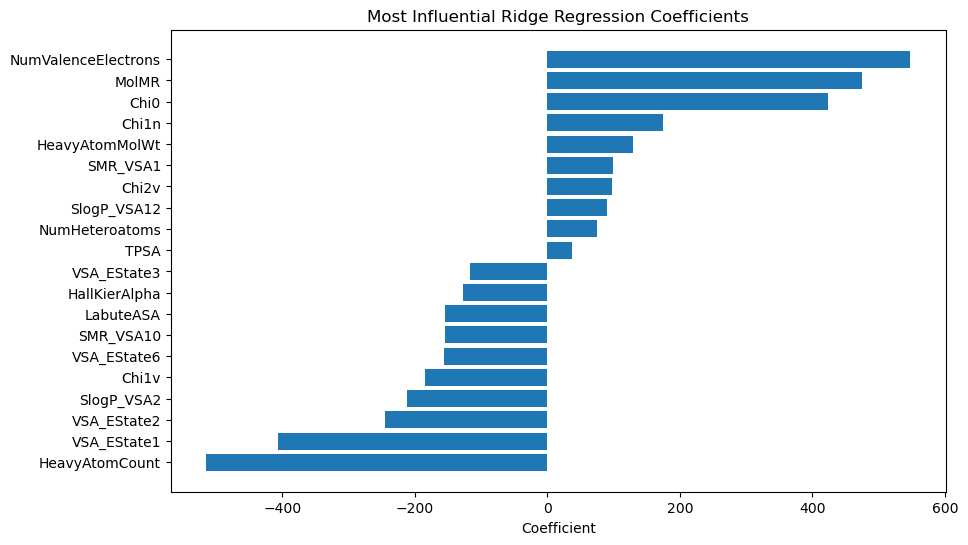

In [21]:
top_coef = pd.concat([top_negative_coef, top_positive_coef])

plt.figure(figsize=(10, 6))
plt.barh(top_coef.index, top_coef.values)
plt.xlabel("Coefficient")
plt.title("Most Influential Ridge Regression Coefficients")
plt.show()